<a href="https://colab.research.google.com/github/sinjashm/Android/blob/main/ML/Module2_Class_Activity.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Module 2 — Class Activity: End-to-End Machine Learning Pipeline

**Duration**: Max 2 hours  
**Format**: Hands-on Guided Lab  

> 📢 **Note**: **No submission is necessary.** This in-class activity is designed to help you practice building end-to-end classification and regression machine learning pipelines step-by-step.

---

## Activity Overview
In this activity, you will work through two complete machine learning tasks:
1. **Part A: Classification Pipeline** — Predict wine type (**Red** vs. **White** wine) based on chemical features using Wine Quality dataset.
2. **Part B: Regression Pipeline** — Predict country **Life Expectancy** based on socio-economic metrics using the Gapminder dataset.

Follow the instructions in each step, replace the `# YOUR CODE HERE` comments with your implementation, and run all cells to test your solution!


---
# Part A: Classification Pipeline (Wine Type Prediction)

### Step A1: Data Loading & Combination
1. Load the Red Wine dataset from `https://raw.githubusercontent.com/tofighi/MachineLearning/master/datasets/winequality-red.csv` (delimiter is `;`).
2. Load the White Wine dataset from `https://github.com/tofighi/MachineLearning/raw/master/datasets/white-wine.csv` (delimiter is `,`).
3. Add a new target column named `color`: set it to `0` for Red wine and `1` for White wine.
4. Concatenate both DataFrames into a single DataFrame named `df_wine`.


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# YOUR CODE HERE
# 1. Read red wine CSV (sep=';')
url_red = 'https://raw.githubusercontent.com/tofighi/MachineLearning/master/datasets/winequality-red.csv'
red_wine = pd.read_csv(url_red,header='infer',sep =';')
# 2. Read white wine CSV
url_white = 'https://github.com/tofighi/MachineLearning/raw/master/datasets/white-wine.csv'
white_wine = pd.read_csv(url_white,header='infer')
# 3. Add 'color' column (0 for red, 1 for white)
red_wine['color'] = 0
white_wine['color'] = 1
# 4. Combine dataframes using pd.concat
wine_df = pd.concat([red_wine,white_wine], ignore_index=True)
# Print dataframe shape and display first 5 rows
wine_df.head()


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,color
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,0
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5,0
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5,0
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6,0
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,0


### Step A2: Exploratory Data Analysis (EDA)
Inspect the dataset summary statistics and generate a plot (e.g. boxplot of `total sulfur dioxide` grouped by `color`).


--- Dataset Information ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6497 entries, 0 to 6496
Data columns (total 13 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         6497 non-null   float64
 1   volatile acidity      6497 non-null   float64
 2   citric acid           6497 non-null   float64
 3   residual sugar        6497 non-null   float64
 4   chlorides             6497 non-null   float64
 5   free sulfur dioxide   6497 non-null   float64
 6   total sulfur dioxide  6497 non-null   float64
 7   density               6497 non-null   float64
 8   pH                    6497 non-null   float64
 9   sulphates             6497 non-null   float64
 10  alcohol               6497 non-null   float64
 11  quality               6497 non-null   int64  
 12  color                 6497 non-null   int64  
dtypes: float64(11), int64(2)
memory usage: 660.0 KB

--- Feature Statistics ---


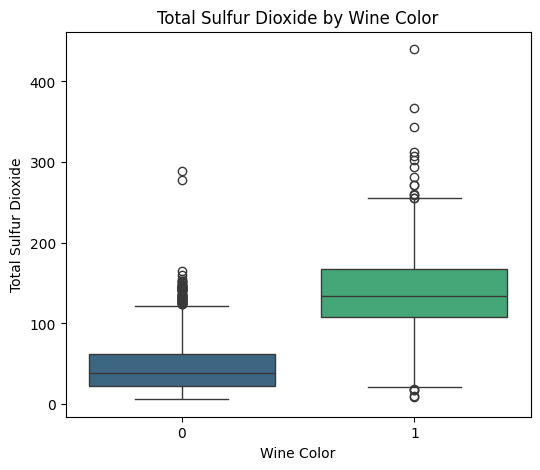

In [3]:
# YOUR CODE HERE
# Display df_wine.info() and df_wine.describe()
print("--- Dataset Information ---")
wine_df.info()

print("\n--- Feature Statistics ---")
wine_df.describe()
plt.figure(figsize=(6, 5))
sns.boxplot(data=wine_df, x='color', y='total sulfur dioxide', palette='viridis')

# Customise titles and labels
plt.title('Total Sulfur Dioxide by Wine Color')
plt.xlabel('Wine Color')
plt.ylabel('Total Sulfur Dioxide')

plt.show()

### Step A3: Feature Matrix ($X$) & Target ($y$) Separation
Define $X$ containing all chemical properties (exclude `color` and `quality`), and $y$ as the target variable `color`.


In [4]:
# YOUR CODE HERE
# Define X and y
X_wine = wine_df[["fixed acidity","volatile acidity","citric acid","residual sugar","chlorides","free sulfur dioxide","total sulfur dioxide","density","pH"	,"sulphates","alcohol"]]
Y_wine = wine_df['color']
# Print X and y shapes
print(f"Feature matrix X shape: {X_wine.shape}")
print(f"Target vector y shape:  {Y_wine.shape}")




Feature matrix X shape: (6497, 11)
Target vector y shape:  (6497,)


### Step A4: Train/Test Split
Split the dataset into 80% Training and 20% Testing sets using `random_state=42`.


In [7]:
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# YOUR CODE HERE
# X_train, X_test, y_train, y_test = ...

X_train, X_test, y_train, y_test = train_test_split(X_wine, Y_wine, test_size=0.20, random_state=42)
knn = KNeighborsClassifier(n_neighbors=9)
knn.fit(X_train, y_train)

# Predict on test set
y_pred = knn.predict(X_test)

print(f"Test Accuracy: {accuracy_score(y_test, y_pred):.4f}\n")
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))
print("\nClassification Report:")
print(classification_report(y_test, y_pred))
# Print shapes of X_train and X_test


Test Accuracy: 0.9400

Confusion Matrix:
[[283  58]
 [ 20 939]]

Classification Report:
              precision    recall  f1-score   support

           0       0.93      0.83      0.88       341
           1       0.94      0.98      0.96       959

    accuracy                           0.94      1300
   macro avg       0.94      0.90      0.92      1300
weighted avg       0.94      0.94      0.94      1300



### Step A5: Classification & Evaluation
Train a `KNeighborsClassifier` with `n_neighbors=5`, predict on test data, and output accuracy and confusion matrix.


In [9]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.model_selection import GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier



# YOUR CODE HERE
# Fit model, make predictions, and calculate accuracy
# 1. k-NN Tuning
#knn_grid = GridSearchCV(KNeighborsClassifier(), {'n_neighbors': [3, 5, 7, 9, 11]}, cv=5)
#knn_grid.fit(X_wine, Y_wine)
#print(f"Best k-NN Params: {knn_grid.best_params_} | Best CV Accuracy: {knn_grid.best_score_:.4f}")

# 2. Logistic Regression Tuning
#lr_grid = GridSearchCV(LogisticRegression(solver='saga', max_iter=10000), {'penalty': ['l1', 'l2']}, cv=5)
#lr_grid.fit(X_wine, Y_wine)
#print(f"Best LogReg Params: {lr_grid.best_params_} | Best CV Accuracy: {lr_grid.best_score_:.4f}")

# 3. Decision Tree Tuning
dt_grid = GridSearchCV(DecisionTreeClassifier(random_state=42), {'criterion': ['gini', 'entropy'], 'max_depth': range(2, 10)}, cv=5)
dt_grid.fit(X_wine, Y_wine)
print(f"Best Tree Params:   {dt_grid.best_params_} | Best CV Accuracy: {dt_grid.best_score_:.4f}")

Best Tree Params:   {'criterion': 'entropy', 'max_depth': 5} | Best CV Accuracy: 0.9825


### Step A6: Hyperparameter Tuning with `GridSearchCV`
Perform a 5-fold cross-validation grid search to find the optimal `n_neighbors` candidate from `[3, 5, 7, 9, 11]`.


In [ ]:
from sklearn.model_selection import GridSearchCV

# YOUR CODE HERE
# Grid search setup, fit, and print best_params_ and best_score_


### Step A7: Scaling via `scikit-learn` Pipeline
Construct a `Pipeline` combining `StandardScaler` and `KNeighborsClassifier(n_neighbors=5)`. Evaluate test set accuracy and compare with unscaled performance.


In [ ]:
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

# YOUR CODE HERE
# Build pipeline, fit on train set, and evaluate on test set


---
# Part B: Regression Pipeline (Life Expectancy Prediction)

### Step B1: Data Loading & Preprocessing
Load the Gapminder dataset from `https://raw.githubusercontent.com/tofighi/MachineLearning/master/datasets/gapminder.csv`. Drop the non-numeric `Region` column.


In [ ]:
# YOUR CODE HERE
# Load dataset and drop 'Region' column
url_gap = 'https://raw.githubusercontent.com/tofighi/MachineLearning/master/datasets/gapminder.csv'
df = pd.read_csv(ur_gap,header='infer')
# Display head of dataframe


### Step B2: Feature & Target Split, Train/Test Split
Separate features $X$ (all columns except `life`) and target $y$ (`life`). Perform a 70% Train / 30% Test split (`random_state=42`).


In [ ]:
# YOUR CODE HERE
# Define X and y, then train_test_split with test_size=0.30


### Step B3: Model Training & Regression Metrics
Train a `LinearRegression` model. Predict on the test set and calculate $R^2$, MAE, and RMSE.


In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

# YOUR CODE HERE
# Fit regressor, predict, and compute metrics


### Step B4: Cross-Validation & Ridge Regularization
1. Compute 5-fold CV $R^2$ score for `LinearRegression`.
2. Tune Ridge regression parameter `alpha` over `np.logspace(-4, 0, 50)` using 10-fold `GridSearchCV`.


In [ ]:
from sklearn.linear_model import Ridge
from sklearn.model_selection import cross_val_score, GridSearchCV

# YOUR CODE HERE
# 1. cross_val_score on LinearRegression

# 2. GridSearchCV on Ridge


### Step B5: Complete Regression Pipeline
Create a pipeline with `StandardScaler` and `Ridge` using the best `alpha` found above. Fit on training data and report final test $R^2$ score.


In [ ]:
# YOUR CODE HERE
# Build Pipeline with StandardScaler and Ridge(alpha=best_alpha)


---
## Summary Checklist
- [ ] Part A: Classification Pipeline completed with data combination, EDA, KNN, GridSearchCV, and Scaling Pipeline.
- [ ] Part B: Regression Pipeline completed with feature extraction, Linear Regression, metrics ($R^2$, MAE, RMSE), Ridge tuning, and Scaled Pipeline.

> 📢 **Reminder**: **No submission is necessary.** Excellent work!
